<a href="https://colab.research.google.com/github/arcctg/kpi-ml-lab5/blob/main/02_cifar10_object_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: CIFAR-10 Object Classification


#### Importing Required Libraries

We import the following libraries:
- **numpy (np)**: Array operations — reshaping, argmax, random sampling
- **matplotlib.pyplot (plt)**: Plotting images, training curves, and prediction charts
- **tensorflow (tf)**: Deep-learning backend powering Keras
- **tensorflow.keras.datasets.cifar10**: Built-in loader for CIFAR-10 (50 000 train + 10 000 test **colour** images, 32×32×3)
- **tensorflow.keras.utils.to_categorical**: One-hot encoding for multi-class labels
- **tensorflow.keras.models / layers**: High-level API for building CNN architectures with `Conv2D`, `MaxPooling2D`, `Flatten`, and `Dense` layers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


#### Loading the CIFAR-10 Dataset

CIFAR-10 is a widely-used benchmark dataset for image classification, bundled inside Keras.

Key characteristics:
- **50 000 training** + **10 000 test** images
- **RGB colour** images of size **32 × 32 × 3** (3 channels)
- **10 mutually exclusive classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- Pixel values are `uint8` in **[0, 255]**
- Labels are integers in **[0, 9]**

Compared to MNIST, CIFAR-10 is significantly harder: images are low-resolution colour photographs of real-world objects with complex backgrounds, not clean handwritten digits on a blank canvas.

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training set — images:", train_images.shape, "| labels:", train_labels.shape)
print("Test set     — images:", test_images.shape,  "| labels:", test_labels.shape)
print("Data type:", train_images.dtype)
print("Pixel value range: [{}, {}]".format(train_images.min(), train_images.max()))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 33s 0us/step
Training set — images: (50000, 32, 32, 3) | labels: (50000, 1)
Test set     — images: (10000, 32, 32, 3) | labels: (10000, 1)
Data type: uint8
Pixel value range: [0, 255]


#### Visualising the First 25 Training Images

We display a 5 × 5 grid of the first 25 training images with their class names.

This serves two purposes:
1. **Sanity check** — confirms data loaded correctly and labels match the visible content
2. **Intuition** — shows the variety and low resolution (32×32) of CIFAR-10. Many images are hard to classify even for humans at this resolution.

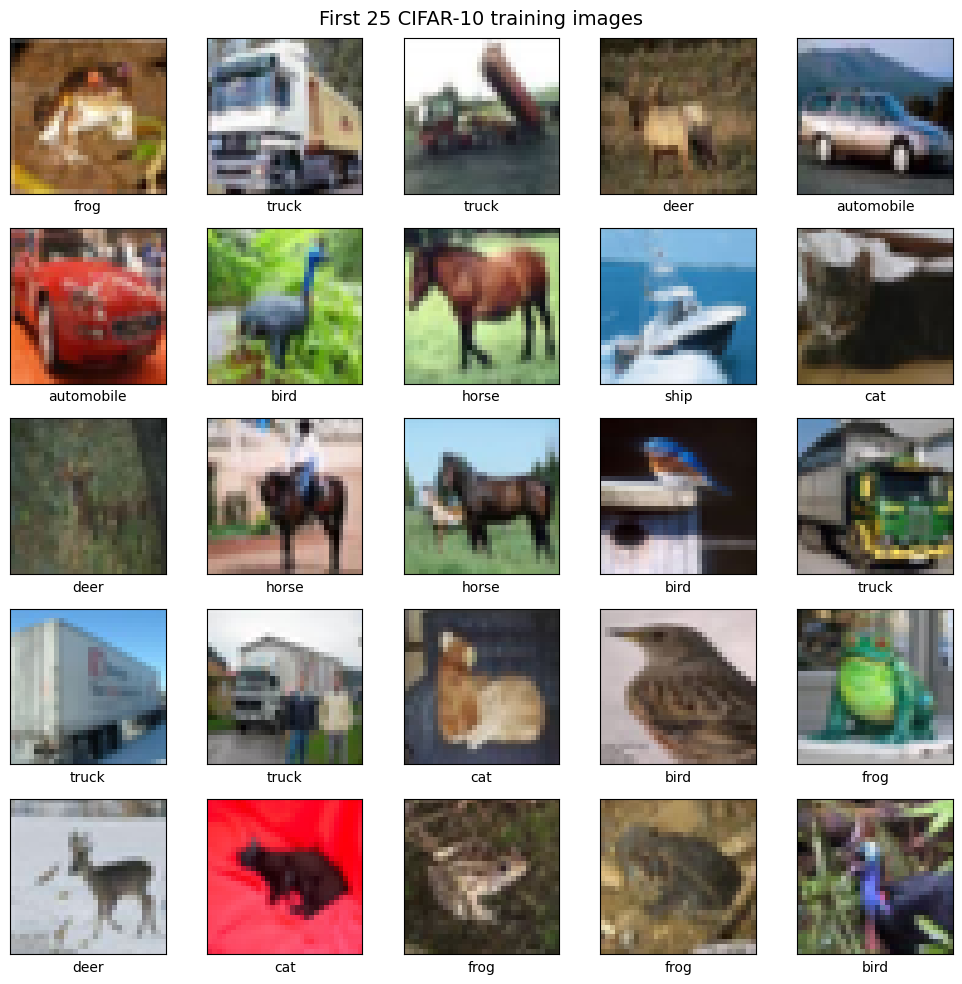

In [3]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.suptitle("First 25 CIFAR-10 training images", fontsize=14)
plt.tight_layout()
plt.show()

#### Data Preprocessing

**1. Normalise pixel values to [0, 1]**
Divide by 255 and cast to `float32`. This keeps inputs in the same numeric range as the initial random weights, greatly accelerating gradient convergence.

**2. One-hot encode labels**
`to_categorical` converts each integer label to a binary vector of length 10, as required by `categorical_crossentropy`.

**Important:** Unlike MNIST, we do **not** flatten the images. Convolutional layers expect the full spatial shape `(32, 32, 3)` to detect local patterns (edges, textures, shapes) via sliding filters.

In [4]:
# Normalise
train_images = train_images.astype('float32') / 255
test_images  = test_images.astype('float32') / 255

# One-hot encode labels
train_labels = to_categorical(train_labels, 10)
test_labels  = to_categorical(test_labels, 10)

print("train_images shape:", train_images.shape, "| dtype:", train_images.dtype)
print("train_labels shape:", train_labels.shape)
print("Pixel value range: [{:.1f}, {:.1f}]".format(train_images.min(), train_images.max()))

train_images shape: (50000, 32, 32, 3) | dtype: float32
train_labels shape: (50000, 10)
Pixel value range: [0.0, 1.0]


#### Defining the CNN Architecture

A fully-connected (Dense) network would flatten the image into a 3072-element vector, discarding all spatial structure. For CIFAR-10 this yields only ~50 % accuracy.

Instead, we use a **Convolutional Neural Network (CNN)** that preserves spatial relationships:

| Layer | Output shape | Parameters | Role |
|-------|-------------|-----------|------|
| Conv2D(32, 3×3, relu) | (30, 30, 32) | 896 | Learns 32 low-level filters (edges, colour blobs) |
| MaxPooling2D(2×2) | (15, 15, 32) | 0 | Halves spatial dimensions, adds translation invariance |
| Conv2D(64, 3×3, relu) | (13, 13, 64) | 18 496 | Learns 64 mid-level feature combinations |
| MaxPooling2D(2×2) | (6, 6, 64) | 0 | Further downsampling |
| Conv2D(64, 3×3, relu) | (4, 4, 64) | 36 928 | Learns 64 high-level semantic features |
| Flatten | (1024,) | 0 | Unrolls the feature map into a vector |
| Dense(64, relu) | (64,) | 65 600 | Non-linear combination of extracted features |
| Dense(10, softmax) | (10,) | 650 | Probability distribution over 10 classes |

**Why this design?**
- Three `Conv2D` layers progressively build a feature hierarchy (edges → textures → object parts)
- `MaxPooling2D` reduces computation and makes the model more robust to small spatial shifts
- A single `Dense(64)` head classifies based on the extracted feature vector

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the Model

- **Optimizer — `adam`**
  Adaptive Moment Estimation. Combines the benefits of RMSProp (adaptive learning rate) and SGD with momentum. Widely considered the best general-purpose optimiser for CNNs.

- **Loss — `categorical_crossentropy`**
  Standard loss for multi-class classification with one-hot encoded labels.

- **Metric — `accuracy`**
  Fraction of correctly classified samples, reported for monitoring.

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the Model

Training parameters:

- **`epochs=15`** — CNNs on CIFAR-10 need more passes than a simple Dense network on MNIST because the data is more complex (colour, real-world objects, backgrounds).
- **`batch_size=64`** — smaller batches provide noisier but more frequent weight updates, which often helps CNNs escape shallow local minima.
- **`validation_split=0.1`** — 5 000 images are withheld for monitoring generalisation. If validation accuracy plateaus while training accuracy keeps rising, the model is overfitting.

Expected training accuracy: **~75–80 %** after 15 epochs with this architecture.

In [7]:
history = model.fit(
    train_images,
    train_labels,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 75ms/step - accuracy: 0.4026 - loss: 1.6251 - val_accuracy: 0.5192 - val_loss: 1.3437
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.5427 - loss: 1.2721 - val_accuracy: 0.5794 - val_loss: 1.1553
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.6062 - loss: 1.1091 - val_accuracy: 0.5992 - val_loss: 1.1358
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - accuracy: 0.6409 - loss: 1.0179 - val_accuracy: 0.6328 - val_loss: 1.0541
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.6666 - loss: 0.9479 - val_accuracy: 0.6682 - val_loss: 0.9634
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.6887 - loss: 0.8873 - val_accuracy: 0.6780 - val_loss: 0.9302
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.7056 - loss: 0.8405 - val_accuracy: 0.6832 - val_loss: 0.9143
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.7221 - loss: 0.7954 - 

#### Training History — Loss and Accuracy Curves

We plot accuracy and loss for both training and validation sets across all epochs.

- **Accuracy plot**: both curves should rise. A growing gap between them signals overfitting.
- **Loss plot**: both curves should fall. If validation loss starts increasing while training loss continues to decrease, the model is memorising the training data.

For CIFAR-10 with this simple CNN, some overfitting is expected after ~10 epochs. Data augmentation or dropout could mitigate this, but are beyond the scope of this lab.

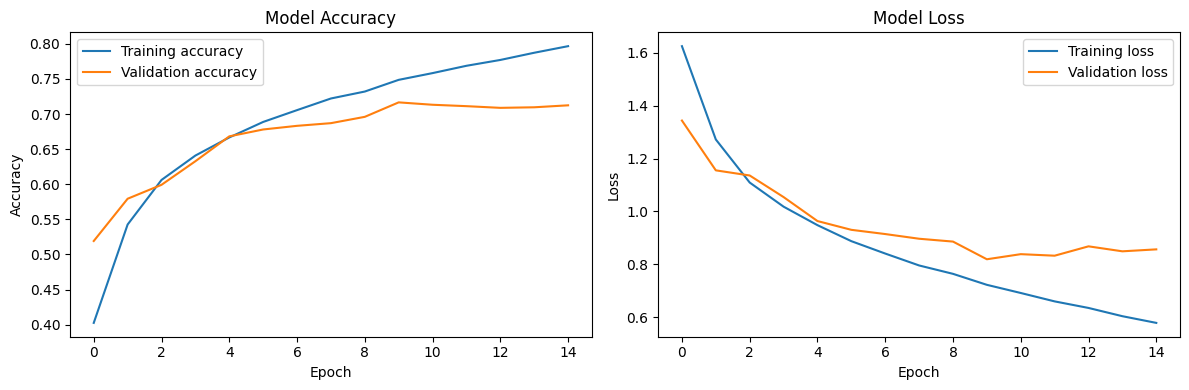

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Training accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Training loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Evaluating on the Test Set

We evaluate the trained model on the held-out 10 000-image test set.

This gives an unbiased estimate of real-world performance. Expected test accuracy for this architecture: approximately **~70–72 %**.

This is significantly lower than MNIST (~98 %) because CIFAR-10 images have far more visual complexity — colour, background clutter, occlusion, and high intra-class variation.

In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}  ({test_acc * 100:.2f} %)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7116 - loss: 0.8961
Test loss:     0.8961
Test accuracy: 0.7116  (71.16 %)


#### Visualising Predictions on Test Images

We randomly sample 10 images from the test set and show:
- **Left**: the original 32×32 image with the true label and predicted label. Correct predictions are shown in green, incorrect in red.
- **Right**: a bar chart of the model's confidence for each of the 10 classes. The predicted class is highlighted in red.

This visualisation helps identify which classes the model confuses (e.g. cat vs. dog, automobile vs. truck).

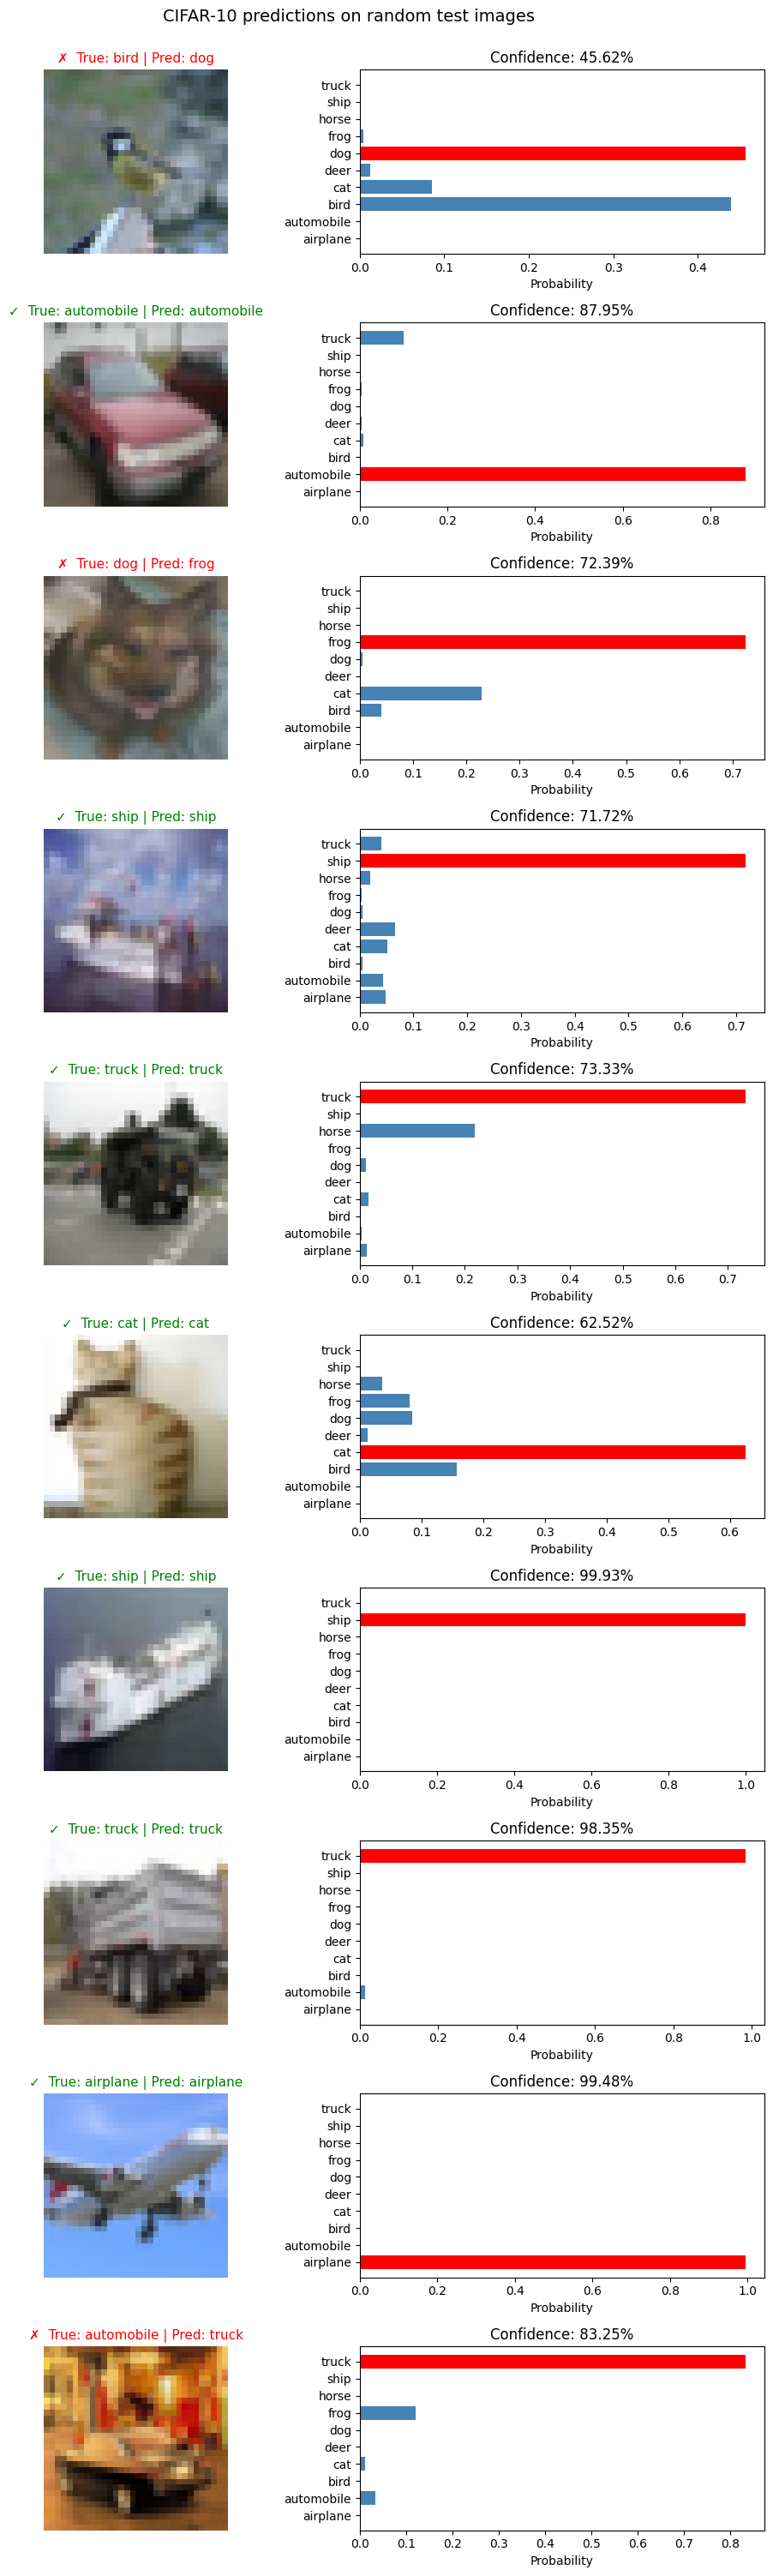

In [10]:
np.random.seed(42)
indices = np.random.choice(len(test_images), 10, replace=False)

fig, axes = plt.subplots(10, 2, figsize=(10, 30))

for row, idx in enumerate(indices):
    img = test_images[idx]
    true_label = np.argmax(test_labels[idx])
    preds = model.predict(img.reshape(1, 32, 32, 3), verbose=0)[0]
    predicted = np.argmax(preds)
    is_correct = predicted == true_label

    # Image
    axes[row, 0].imshow(img)
    colour = 'green' if is_correct else 'red'
    mark = '✓' if is_correct else '✗'
    axes[row, 0].set_title(
        f"{mark}  True: {class_names[true_label]} | Pred: {class_names[predicted]}",
        fontsize=11, color=colour
    )
    axes[row, 0].axis('off')

    # Confidence bar chart
    bar_colors = ['red' if j == predicted else 'steelblue' for j in range(10)]
    axes[row, 1].barh(range(10), preds, color=bar_colors)
    axes[row, 1].set_yticks(range(10))
    axes[row, 1].set_yticklabels(class_names)
    axes[row, 1].set_xlabel('Probability')
    axes[row, 1].set_title(f'Confidence: {preds[predicted]:.2%}')

plt.suptitle('CIFAR-10 predictions on random test images', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

#### Saving the Trained Model

We save the complete model (architecture + weights + optimiser state) in the `.keras` format.

This file can later be loaded with `load_model('cifar10_model.keras')` for inference without retraining.

In [11]:
model.save('cifar10_model.keras')
print("Model saved to: cifar10_model.keras")

Model saved to: cifar10_model.keras


#### Conclusions

In this task we designed and trained a **Convolutional Neural Network** to classify 32×32 colour images from the CIFAR-10 dataset into 10 categories.

**Key results:**
- The 3-layer CNN (Conv2D 32 → Conv2D 64 → Conv2D 64 → Dense 64 → Dense 10) achieves approximately **~70–72 %** accuracy on the test set after 15 epochs.
- This is a significant improvement over a naive Dense-only baseline (~50 %), confirming that convolutional layers are essential for capturing spatial features in image data.

**Observations:**
- The training curves show some overfitting after ~10 epochs (training accuracy continues to rise while validation accuracy plateaus). This could be mitigated with techniques like **dropout**, **data augmentation**, or **batch normalisation**.
- The model performs best on visually distinctive classes (frog, ship, truck) and struggles more with visually similar pairs (cat/dog, automobile/truck).
- The `adam` optimiser provides stable convergence and is well-suited for CNN training.

**Comparison with MNIST (Task 1):**
- MNIST achieves ~98 % with a simple 2-layer Dense network, while CIFAR-10 requires a CNN and still only reaches ~70 %. This illustrates how much harder real-world colour image classification is compared to clean grayscale digit recognition.
- State-of-the-art models on CIFAR-10 (e.g. ResNet, EfficientNet) achieve 95 %+ accuracy using much deeper architectures, augmentation, and regularisation.